# Notebook 06 — Temporal Train / Val / Test Split

**Input:** `outputs/kkbox_features.parquet` (970,960 rows × 40 cols)  
**Outputs:** `outputs/train.parquet`, `outputs/val.parquet`, `outputs/test.parquet`, `outputs/class_weight_ratio.txt`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import roc_auc_score
from pathlib import Path

ROOT    = Path("..").resolve()
OUTPUTS = ROOT / "outputs"

print(f"Project root : {ROOT}")
print(f"Outputs dir  : {OUTPUTS}")

Project root : C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction
Outputs dir  : C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction\outputs


## Section 1 — Why Temporal Split?

### The problem with random splitting

The churn label (`is_churn`) is fixed at **March 2017**. A naive random 80/10/10 split would scatter customers with old and new registration dates evenly across train, val, and test. This creates two problems:

1. **Distribution leakage**: Newer registrants have shorter account histories and therefore systematically different feature distributions (fewer transactions, shorter `days_as_member`, less listening history). A random split masks this distribution shift — the model sees the same distribution at training and test time, but in production you always score on whoever is active now, which skews newer.

2. **Registration-date-correlated patterns**: Features like `membership_tenure` and `days_as_member` are direct functions of registration date. Random splitting exposes the model to the full tenure range in both train and test, masking how well it generalises across cohorts.

### Split boundaries

| Split | `registration_init_time` | Rationale |
|-------|--------------------------|----------|
| **Train** | < 20160101 (and = 0) | Customers registered before 2016 — long history, stable signal |
| **Val**   | [20160101, 20160701) | Mid-2016 cohort — hyperparameter tuning |
| **Test**  | ≥ 20160701           | Second-half 2016 cohort — held-out final evaluation |

> **Note on `registration_init_time = 0`**: 109,993 customers are absent from `members_v3.csv` and were filled with 0. Assigned to **train** (conservative: unknown-date users are likely older customers with full history).

## Section 2 — Data Leakage Audit

Before defining the feature set, we audit each raw date column for **target leakage** — where a feature is derived from the same March 2017 activity that determines `is_churn`.

### Root cause

`transactions_v2.csv` covers **January – March 2017**, which is the same window as the churn label:
- If a customer **renewed** their subscription in March 2017 → a new transaction is recorded → `last_expire_date` is pushed to April 2017+ → `is_churn = 0`.
- If a customer **did not renew** → no new transaction → `last_expire_date` stays at or before March 31 → `is_churn = 1`.

This means `last_expire_date` and `last_transaction` are not *predictors* of churn — they are **consequences** of the same renewal decision that defines the label.

In [2]:
df = pd.read_parquet(OUTPUTS / "kkbox_features.parquet")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} cols")

Loaded: 970,960 rows x 40 cols


In [3]:
# --- Leakage evidence: last_expire_date ---
LABEL_CUTOFF = 20170331

expired_by_cutoff = df[df["last_expire_date"] <= LABEL_CUTOFF]
still_active      = df[df["last_expire_date"] >  LABEL_CUTOFF]

print("last_expire_date vs is_churn:")
print("  last_expire_date <= 20170331 (expired by label cutoff):")
print("    n=%d   churn_rate=%.1f%%" % (len(expired_by_cutoff), expired_by_cutoff["is_churn"].mean()*100))
print("  last_expire_date > 20170331  (still active past cutoff):")
print("    n=%d  churn_rate=%.1f%%" % (len(still_active), still_active["is_churn"].mean()*100))
print()

# Single-feature AUCs
log_fill = df["days_since_last_log"].fillna(df["days_since_last_log"].median())
audit = [
    ("last_expire_date  [LEAKY]",  df["last_expire_date"]),
    ("last_transaction  [LEAKY]",  df["last_transaction"]),
    ("first_transaction [redundant]", df["first_transaction"]),
    ("auto_renew_rate   [legit]",  -df["auto_renew_rate"]),
    ("cancel_rate       [legit]",   df["cancel_rate"]),
    ("days_since_last_log [legit]", log_fill),
    ("days_as_member    [legit]",  -df["days_as_member"]),
]
print("Single-feature AUC (higher = more predictive; >0.65 and leaky = problem):")
for name, scores in audit:
    auc = roc_auc_score(df["is_churn"], scores)
    # Flip if below 0.5 (directionally inverted)
    effective_auc = max(auc, 1 - auc)
    print("  %-40s AUC=%.4f" % (name, effective_auc))

last_expire_date vs is_churn:


  last_expire_date <= 20170331 (expired by label cutoff):
    n=57666   churn_rate=70.5%
  last_expire_date > 20170331  (still active past cutoff):
    n=913294  churn_rate=5.1%

Single-feature AUC (higher = more predictive; >0.65 and leaky = problem):


  last_expire_date  [LEAKY]                AUC=0.6038


  last_transaction  [LEAKY]                AUC=0.7413


  first_transaction [redundant]            AUC=0.5343
  auto_renew_rate   [legit]                AUC=0.7569


  cancel_rate       [legit]                AUC=0.6240
  days_since_last_log [legit]              AUC=0.5791


  days_as_member    [legit]                AUC=0.5891


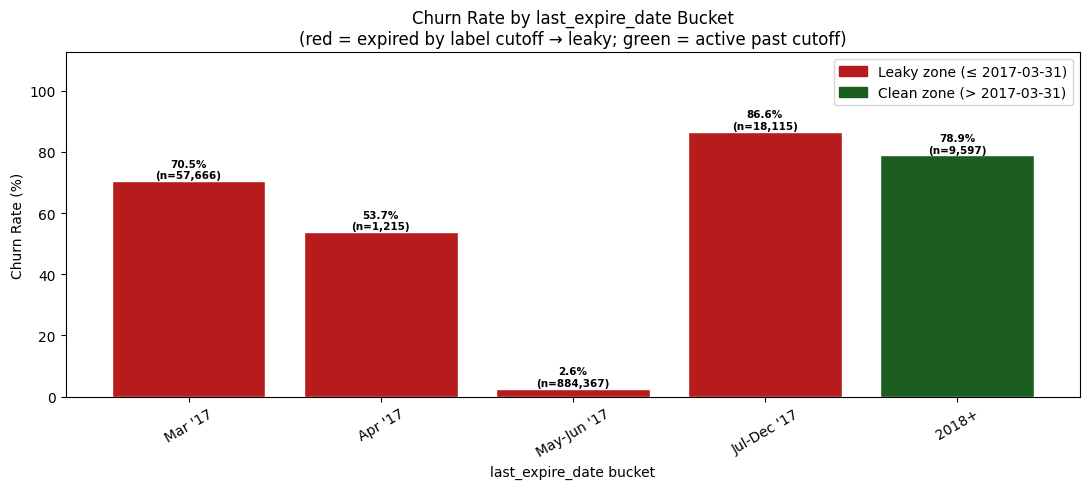

Saved: outputs/06_leakage_audit.png

CONCLUSION: last_expire_date and last_transaction are EXCLUDED from the feature set.
            first_transaction is EXCLUDED (fully redundant with days_as_member).


In [4]:
# Visualise the leakage: churn rate by last_expire_date bin
df_plot = df.copy()
bins   = [0, 20160101, 20170101, 20170301, 20170331, 20170401, 20170601, 20180101, 99999999]
labels = ["pre-2016", "2016", "Jan-Feb '17", "Mar '17", "Apr '17", "May-Jun '17", "Jul-Dec '17", "2018+"]
df_plot["expire_bin"] = pd.cut(df_plot["last_expire_date"], bins=bins, labels=labels, right=True)

cr = df_plot.groupby("expire_bin", observed=True)["is_churn"].mean() * 100
cnt = df_plot.groupby("expire_bin", observed=True)["is_churn"].count()

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#B71C1C" if lbl in ["pre-2016", "2016", "Jan-Feb '17", "Mar '17"]
          else "#1B5E20" for lbl in labels]
bars = ax.bar(cr.index.astype(str), cr.values, color=colors, edgecolor="white")
for bar, val, n in zip(bars, cr.values, cnt.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            "%.1f%%\n(n=%s)" % (val, f"{n:,}"),
            ha="center", va="bottom", fontsize=7.5, fontweight="bold")
ax.set_xlabel("last_expire_date bucket")
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by last_expire_date Bucket\n(red = expired by label cutoff → leaky; green = active past cutoff)")
ax.set_ylim(0, cr.max() * 1.3)
ax.tick_params(axis="x", rotation=30)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#B71C1C", label="Leaky zone (≤ 2017-03-31)"),
                   Patch(color="#1B5E20", label="Clean zone (> 2017-03-31)")],
          loc="upper right")
plt.tight_layout()
plt.savefig(OUTPUTS / "06_leakage_audit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/06_leakage_audit.png")
print()
print("CONCLUSION: last_expire_date and last_transaction are EXCLUDED from the feature set.")
print("            first_transaction is EXCLUDED (fully redundant with days_as_member).")

## Section 3 — Execute Split

In [5]:
# --- One-hot encode segment_label (string column) ---
segment_dummies = pd.get_dummies(df["segment_label"], prefix="segment").astype(int)
df = pd.concat([df.drop(columns=["segment_label"]), segment_dummies], axis=1)
print("Segment columns:", [c for c in df.columns if c.startswith("segment_")])
print(f"Shape after encoding: {df.shape}")

Segment columns: ['segment_At-Risk', 'segment_Casual Listeners', 'segment_Dormant', 'segment_Power Users']
Shape after encoding: (970960, 43)


In [6]:
# --- Define feature columns ---
# Excluded columns and rationale:
#   msno                  — customer ID (not a feature)
#   is_churn              — target variable
#   registration_init_time— split key; using as feature would directly encode cohort age
#   last_expire_date      — TARGET LEAKAGE: encodes March 2017 renewal decision
#   last_transaction      — TARGET LEAKAGE: recent transactions = March 2017 renewals
#   first_transaction     — REDUNDANT: fully captured by days_as_member / membership_tenure
#   last_log_date         — REDUNDANT: captured by days_since_last_log
#   first_log_date        — REDUNDANT: captured by active_days

NON_FEATURE_COLS = {
    "msno",
    "is_churn",
    "registration_init_time",
    "last_expire_date",
    "last_transaction",
    "first_transaction",
    "last_log_date",
    "first_log_date",
}

FEATURE_COLS = [c for c in df.columns if c not in NON_FEATURE_COLS]
TARGET = "is_churn"

print("Feature columns (%d):" % len(FEATURE_COLS))
for i, col in enumerate(FEATURE_COLS):
    print("  %2d. %s" % (i+1, col))

Feature columns (35):
   1. total_paid
   2. avg_payment
   3. max_payment
   4. discount_rate
   5. n_transactions
   6. avg_plan_days
   7. auto_renew_rate
   8. cancel_rate
   9. days_as_member
  10. n_payment_methods
  11. total_secs
  12. avg_daily_secs
  13. max_daily_secs
  14. total_songs_played
  15. completion_rate
  16. skip_rate
  17. unique_songs_ratio
  18. active_days
  19. days_since_last_log
  20. city_freq_rank
  21. age
  22. membership_tenure
  23. gender_male
  24. gender_female
  25. gender_unknown
  26. reg_via_4
  27. reg_via_3
  28. reg_via_9
  29. reg_via_7
  30. reg_via_11
  31. reg_via_other
  32. segment_At-Risk
  33. segment_Casual Listeners
  34. segment_Dormant
  35. segment_Power Users


In [7]:
# --- Apply temporal split ---
rit = df["registration_init_time"]

# Customers with rit=0 (absent from members_v3) → assigned to train
train_mask = (rit == 0) | (rit < 20160101)
val_mask   = (rit >= 20160101) & (rit < 20160701)
test_mask  = (rit >= 20160701)

# Every row must land in exactly one split
assert (train_mask.astype(int) + val_mask.astype(int) + test_mask.astype(int) == 1).all(), \
    "Assignment error: some rows are unassigned or double-assigned!"

train_df = df[train_mask].reset_index(drop=True)
val_df   = df[val_mask].reset_index(drop=True)
test_df  = df[test_mask].reset_index(drop=True)

total = len(df)
rates = [s[TARGET].mean() for s in [train_df, val_df, test_df]]

print("Split sizes and churn rates:")
print("  %-6s: %7s  (%5s%%)  churn=%.2f%%" % ("Train", f"{len(train_df):,}", f"{len(train_df)/total*100:.1f}", rates[0]*100))
print("  %-6s: %7s  (%5s%%)  churn=%.2f%%" % ("Val",   f"{len(val_df):,}",   f"{len(val_df)/total*100:.1f}",   rates[1]*100))
print("  %-6s: %7s  (%5s%%)  churn=%.2f%%" % ("Test",  f"{len(test_df):,}",  f"{len(test_df)/total*100:.1f}",  rates[2]*100))
print("  %-6s: %7s" % ("Total", f"{total:,}"))

rate_spread = max(rates) - min(rates)
if rate_spread > 0.05:
    print()
    print("WARNING: churn rate spread is %.2fpp — exceeds 5pp threshold." % (rate_spread*100))
    print("  Churn behaviour differs across registration cohorts.")
    print("  Evaluate val and test independently to measure cohort generalisation.")
else:
    print()
    print("Churn rate spread: %.2fpp — within 5pp threshold (splits are balanced)." % (rate_spread*100))

Split sizes and churn rates:
  Train : 742,546  ( 76.5%)  churn=8.92%
  Val   : 103,142  ( 10.6%)  churn=9.81%
  Test  : 125,272  ( 12.9%)  churn=8.77%
  Total : 970,960

Churn rate spread: 1.04pp — within 5pp threshold (splits are balanced).


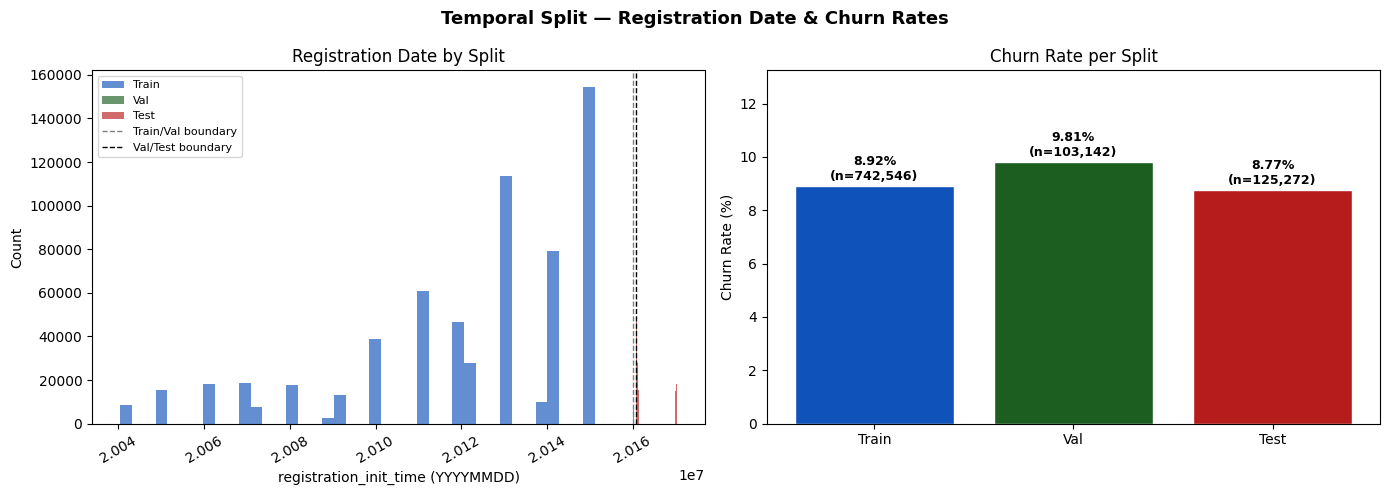

Saved: outputs/06_split_distributions.png


In [8]:
# --- Visualise split distributions ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Temporal Split — Registration Date & Churn Rates", fontsize=13, fontweight="bold")

ax = axes[0]
for label, sub_df, color in [("Train", train_df, "#0F52BA"),
                               ("Val",   val_df,   "#1B5E20"),
                               ("Test",  test_df,  "#B71C1C")]:
    rit_vals = sub_df["registration_init_time"].replace(0, np.nan).dropna()
    ax.hist(rit_vals, bins=40, alpha=0.65, label=label, color=color)
ax.axvline(20160101, color="gray", linestyle="--", linewidth=1, label="Train/Val boundary")
ax.axvline(20160701, color="black", linestyle="--", linewidth=1, label="Val/Test boundary")
ax.set_xlabel("registration_init_time (YYYYMMDD)")
ax.set_ylabel("Count")
ax.set_title("Registration Date by Split")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=30)

ax = axes[1]
split_names  = ["Train", "Val", "Test"]
split_churn  = [s[TARGET].mean() * 100 for s in [train_df, val_df, test_df]]
split_sizes  = [len(s) for s in [train_df, val_df, test_df]]
colors = ["#0F52BA", "#1B5E20", "#B71C1C"]
bars = ax.bar(split_names, split_churn, color=colors, edgecolor="white")
for bar, val, n in zip(bars, split_churn, split_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            "%.2f%%\n(n=%s)" % (val, f"{n:,}"),
            ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate per Split")
ax.set_ylim(0, max(split_churn) * 1.35)

plt.tight_layout()
plt.savefig(OUTPUTS / "06_split_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/06_split_distributions.png")

## Section 4 — Class Imbalance

In [9]:
overall_churn_rate = df[TARGET].mean()
n_total    = len(df)
n_minority = int(df[TARGET].sum())
n_majority = n_total - n_minority
class_weight_ratio = n_majority / n_minority

print("Class Imbalance Summary")
print("-" * 42)
print("  Total customers  : %10s" % f"{n_total:,}")
print("  Churned (1)      : %10s  (%.2f%%)" % (f"{n_minority:,}", overall_churn_rate*100))
print("  Not churned (0)  : %10s  (%.2f%%)" % (f"{n_majority:,}", (1-overall_churn_rate)*100))
print("  Class weight ratio (majority/minority): %.4f" % class_weight_ratio)
print()
print("Usage:")
print("  XGBoost / LightGBM : scale_pos_weight=%.4f" % class_weight_ratio)
print("  sklearn            : class_weight={0: 1, 1: %.4f}" % class_weight_ratio)

ratio_path = OUTPUTS / "class_weight_ratio.txt"
ratio_path.write_text(
    "class_weight_ratio=%.6f\n"
    "n_majority=%d\n"
    "n_minority=%d\n"
    "overall_churn_rate=%.6f\n" % (class_weight_ratio, n_majority, n_minority, overall_churn_rate)
)
print("\nSaved: %s" % ratio_path)

Class Imbalance Summary
------------------------------------------
  Total customers  :    970,960
  Churned (1)      :     87,330  (8.99%)
  Not churned (0)  :    883,630  (91.01%)
  Class weight ratio (majority/minority): 10.1183

Usage:
  XGBoost / LightGBM : scale_pos_weight=10.1183
  sklearn            : class_weight={0: 1, 1: 10.1183}

Saved: C:\Users\h11la\OneDrive\Documents\00 Portfolio\Customer Analytics ML Pipeline\retail-clv-churn-prediction\outputs\class_weight_ratio.txt


## Section 5 — Save

In [10]:
SAVE_COLS = ["msno"] + FEATURE_COLS + [TARGET]

train_df[SAVE_COLS].to_parquet(OUTPUTS / "train.parquet", index=False)
val_df[SAVE_COLS].to_parquet(OUTPUTS   / "val.parquet",   index=False)
test_df[SAVE_COLS].to_parquet(OUTPUTS  / "test.parquet",  index=False)

print("Saved:")
print("  outputs/train.parquet  -> %s rows x %d cols" % (f"{len(train_df):,}", len(SAVE_COLS)))
print("  outputs/val.parquet    -> %s rows x %d cols" % (f"{len(val_df):,}",   len(SAVE_COLS)))
print("  outputs/test.parquet   -> %s rows x %d cols" % (f"{len(test_df):,}",  len(SAVE_COLS)))
print("\nFeature columns (%d): %s" % (len(FEATURE_COLS), FEATURE_COLS))
print("Target: %s" % TARGET)

# Null check
print("\nNull check across feature columns:")
for name, sdf in [("train", train_df), ("val", val_df), ("test", test_df)]:
    nulls = sdf[FEATURE_COLS].isnull().sum().sum()
    print("  %s: %d nulls" % (name, nulls))

Saved:
  outputs/train.parquet  -> 742,546 rows x 37 cols
  outputs/val.parquet    -> 103,142 rows x 37 cols
  outputs/test.parquet   -> 125,272 rows x 37 cols

Feature columns (35): ['total_paid', 'avg_payment', 'max_payment', 'discount_rate', 'n_transactions', 'avg_plan_days', 'auto_renew_rate', 'cancel_rate', 'days_as_member', 'n_payment_methods', 'total_secs', 'avg_daily_secs', 'max_daily_secs', 'total_songs_played', 'completion_rate', 'skip_rate', 'unique_songs_ratio', 'active_days', 'days_since_last_log', 'city_freq_rank', 'age', 'membership_tenure', 'gender_male', 'gender_female', 'gender_unknown', 'reg_via_4', 'reg_via_3', 'reg_via_9', 'reg_via_7', 'reg_via_11', 'reg_via_other', 'segment_At-Risk', 'segment_Casual Listeners', 'segment_Dormant', 'segment_Power Users']
Target: is_churn

Null check across feature columns:
  train: 0 nulls
  val: 0 nulls
  test: 0 nulls
